# Selección distrito
> Cuaderno 1 de 5 del TFM

| Sección | Contenido | Resultado |
|---|---|---|
| 0 | Configuración | - |
| 1 | Lectura datasets (histórico y puntos de medida) | - |
| 2 | Función carga media y DCL | - |
| 3 | Perfil horario carga media todo distritos | -|
| 4 | Ranking distritos por DCL | Chamberí mayor DCL |



La selección del distrito se realiza con cuatro meses representativos del último año del 
periodo de estudio, febrero, mayo, octubre y noviembre de 2025, dos por semestre y sin 
periodo estival ni festivos prolongados, para caracterizar el patrón laborable habitual y 
reciente de congestión para el que se desea proponer soluciones. Para cada mes se 
carga el fichero de puntos de medida y el histórico de tráfico. Después, se combinan 
ambas fuentes de datos a través del identificador de sensor y se crean las variables 
temporales de hora, día de la semana y tipo de día (laborable / no laborable). Por último, 
los registros se agregan por distrito, tipo de día y hora, acumulando los cuatro meses y 
obteniendo la carga media ponderada por cada hora. Se selecciona el distrito con el 
mayor valor de DCL, ya que es el contexto donde las soluciones para reducir el tráfico 
matutino asociado al calendario laboral resultan relevantes.  

## 0. Configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from pathlib import Path


In [10]:
BASE_DIR = Path(r'C:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\dataset')

RUTAS_MESES_EXPLORATORIOS = [
    {"historico": BASE_DIR / "historico" / "022025.zip", "ubicacion": BASE_DIR / "ptos_medida" / "202502.csv"},
    {"historico": BASE_DIR / "historico" / "052025.zip", "ubicacion": BASE_DIR / "ptos_medida" / "202505.csv"},
    {"historico": BASE_DIR / "historico" / "102025.zip", "ubicacion": BASE_DIR / "ptos_medida" / "202510.csv"},
    {"historico": BASE_DIR / "historico" / "112025.zip", "ubicacion": BASE_DIR / "ptos_medida" / "202511.csv"},]

SEPARADOR = ';'
FORMATO_FECHA = '%Y-%m-%d %H:%M:%S'

CARPETA_SALIDA = Path(r'C:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\resultados\distritos')
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)

DISTRITOS = {
    1: 'Centro',        2: 'Arganzuela',   3: 'Retiro',       4: 'Salamanca',
    5: 'Chamartín',     6: 'Tetuán',       7: 'Chamberí',     8: 'Fuencarral-El Pardo',
    9: 'Moncloa-Aravaca', 10: 'Latina',    11: 'Carabanchel', 12: 'Usera',
    13: 'Puente de Vallecas', 14: 'Moratalaz', 15: 'Ciudad Lineal', 16: 'Hortaleza',
    17: 'Villaverde',   18: 'Villa de Vallecas', 19: 'Vicálvaro', 20: 'San Blas-Canillejas',
    21: 'Barajas'}

HORAS_PUNTA = (7, 8, 9)

## 1. Lectura histórico y puntos de medida

Ahora vamos a cargar para cada uno de los cuatro meses el dataset de puntos de medida que contiene la ubicación de los sensores de cada mes, y el histórico de tráfico el cual vamos a leer en bloques.
Adicionalmente, como nos centramos en la simulación urbana, filtramos para quedarnos con los registros asociados (tipo_elem = URB).

Una vez ya hayamos leído la información correspondiente se agregan por distrito, tipo de dia y hora, acumulando todos los meses.

In [11]:
COLUMNAS = ["id", "fecha", "tipo_elem", "carga"]
TAM_BLOQUE = 2_000_000

acumulado, censo_sensores = [], []

for i, mes in enumerate(RUTAS_MESES_EXPLORATORIOS, start=1):
    print(f"Mes {i}/{len(RUTAS_MESES_EXPLORATORIOS)}")
    ubicacion = pd.read_csv(mes["ubicacion"], sep=SEPARADOR, encoding='latin-1',
                            usecols=["id", "distrito", "tipo_elem"])
    ubicacion["distrito"] = pd.to_numeric(ubicacion["distrito"], errors="coerce")
    ubicacion = ubicacion.dropna(subset=["distrito"])
    ubicacion["distrito"] = ubicacion["distrito"].astype(int)
    ubicacion = ubicacion[(ubicacion["tipo_elem"] == 'URB') &
                          (ubicacion["distrito"].isin(DISTRITOS))]

    mapeo = ubicacion.set_index("id")["distrito"].to_dict()
    censo_sensores.append(ubicacion.groupby("distrito")["id"].nunique().rename(f"mes_{i}"))

    for bloque in pd.read_csv(mes["historico"], sep=SEPARADOR, usecols=COLUMNAS,
                              chunksize=TAM_BLOQUE, encoding='latin-1', compression='zip'):
        bloque = bloque[bloque["id"].isin(mapeo)].copy()
        if bloque.empty:
            continue
        bloque["carga"] = pd.to_numeric(bloque["carga"], errors="coerce")
        bloque = bloque[bloque["carga"] >= 0]
        bloque["fecha"] = pd.to_datetime(bloque["fecha"], format=FORMATO_FECHA, errors="coerce")
        bloque["distrito"] = bloque["id"].map(mapeo)
        bloque["hora"] = bloque["fecha"].dt.hour
        bloque["es_laborable"] = bloque["fecha"].dt.dayofweek < 5
        acumulado.append(bloque.groupby(["distrito", "es_laborable", "hora"])["carga"]
                         .agg(suma='sum', mediciones='count').reset_index())
        del bloque; gc.collect()

# Agregación ponderada de los cuatro meses
bruto = pd.concat(acumulado, ignore_index=True)
df = (bruto.groupby(["distrito", "es_laborable", "hora"])[["suma", "mediciones"]].sum().reset_index())
df["carga_media"] = df["suma"] / df["mediciones"]

sensores = pd.concat(censo_sensores, axis=1).min(axis=1).rename("sensores_estables")
print(f"\nDistritos con datos: {df['distrito'].nunique()}   Filas: {len(df)}")

Mes 1/4
Mes 2/4
Mes 3/4
Mes 4/4

Distritos con datos: 21   Filas: 1008


In [12]:
print(df.shape)
print(df['distrito'].unique())
print(df['hora'].unique())
df.head()

(1008, 6)
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


,distrito,es_laborable,hora,suma,mediciones,carga_media
0,1,False,0,501553,19861,25.253159
1,1,False,1,451638,19862,22.738798
2,1,False,2,395227,19820,19.940817
3,1,False,3,341262,19759,17.271218
4,1,False,4,301520,19721,15.289286


Como estamos agrupando por distrito, es_laborable y hora, y tenemos 21 distritos x 2 tipos para es_laborable x 24 horas = 1008 filas, luego es coherente la salida obtenida.

## 2. Carga media y DCL

Representamos los perfiles de carga media de todos los distritos tanto en los días laborables como en los no laborables. 

A continuación se obtiene la carga media de cada hora agrupando los registros  por distrito, tipo de día y hora. Adicionalmente, se calcula el Diferencial de Carga Laborable (DCL) ya que nos va a ayudar con la elección. 

In [13]:
def carga_media_franja(codigo, laborable, horas=HORAS_PUNTA):
    d = df[(df["distrito"] == codigo) & (df["es_laborable"] == laborable) & (df["hora"].isin(horas))]
    return np.average(d["carga_media"], weights=d["mediciones"]) if len(d) else np.nan

def carga_media_dia(codigo, laborable=True):
    d = df[(df["distrito"] == codigo) & (df["es_laborable"] == laborable)]
    return np.average(d["carga_media"], weights=d["mediciones"]) if len(d) else np.nan

## 3. Perfiles horarios de todos los distritos

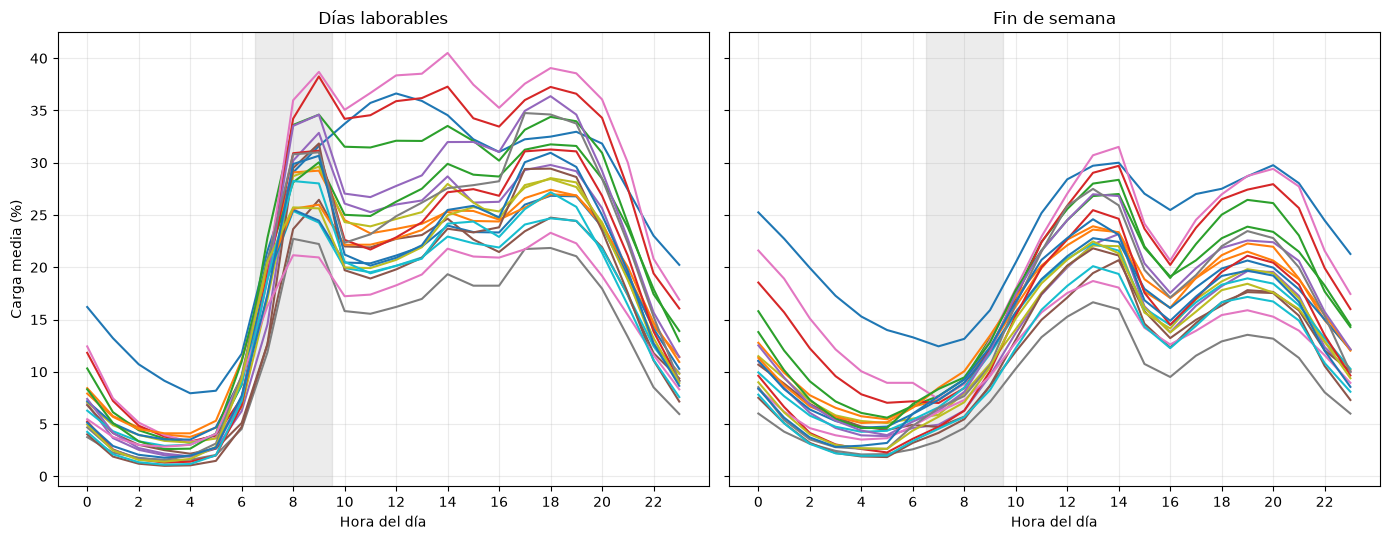

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for codigo, nombre in DISTRITOS.items():
    lab   = df[(df["distrito"] == codigo) & (df["es_laborable"])].sort_values("hora")
    finde = df[(df["distrito"] == codigo) & (~df["es_laborable"])].sort_values("hora")
    if lab.empty:
        continue
    axes[0].plot(lab["hora"], lab["carga_media"])
    axes[1].plot(finde["hora"], finde["carga_media"])

axes[0].set_title("Días laborables")
axes[1].set_title("Fin de semana")
for ax in axes:
    ax.axvspan(min(HORAS_PUNTA) - 0.5, max(HORAS_PUNTA) + 0.5, alpha=0.15, color="grey", zorder=0)
    ax.set_xlabel("Hora del día")
    ax.set_xticks(range(0, 24, 2))
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Carga media (%)")

fig.tight_layout()
fig.savefig(CARPETA_SALIDA / "perfil_horario_todos_distritos.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Ranking distritos por mayor DCL

In [15]:
ranking = pd.DataFrame({'codigo': list(DISTRITOS), 'distrito': list(DISTRITOS.values())})
ranking["punta_lab"]    = ranking["codigo"].apply(lambda c: carga_media_franja(c, True))
ranking["punta_no_lab"] = ranking["codigo"].apply(lambda c: carga_media_franja(c, False))
ranking["dia_lab"]      = ranking["codigo"].apply(carga_media_dia)
ranking["DCL"]          = ranking["punta_lab"] - ranking["punta_no_lab"]
ranking = ranking.merge(sensores, left_on="codigo", right_index=True, how="left")
ranking = ranking.sort_values("DCL", ascending=False).reset_index(drop=True)
ranking.insert(0, "Puesto", ranking.index + 1)
cols = ["Puesto", "distrito", "sensores_estables", "punta_lab", "punta_no_lab", "DCL"]
print("RANKING DE DISTRITOS POR DIFERENCIAL DE CARGA LABORABLE (DCL)\n")
print(ranking[cols].round(2).to_string(index=False))
ranking.to_csv(CARPETA_SALIDA / "ranking_distritos_completo.csv", index=False)

print(f"\nDistrito de mayor DCL {ranking.iloc[0]['distrito']}"
      f"  (DCL = {ranking.iloc[0]['DCL']:.2f})")

RANKING DE DISTRITOS POR DIFERENCIAL DE CARGA LABORABLE (DCL)

 Puesto            distrito  sensores_estables  punta_lab  punta_no_lab   DCL
      1            Chamberí                141      31.36          9.73 21.64
      2           Salamanca                195      30.76          9.23 21.53
      3              Retiro                139      30.36         10.05 20.31
      4       Ciudad Lineal                385      28.99          8.79 20.20
      5           Moratalaz                104      27.13          7.04 20.09
      6   Villa de Vallecas                 81      27.49          8.33 19.16
      7           Chamartín                316      25.88          6.97 18.91
      8 San Blas-Canillejas                295      25.06          6.19 18.87
      9           Hortaleza                366      24.74          6.18 18.56
     10     Moncloa-Aravaca                252      25.12          8.21 16.91
     11          Arganzuela                199      26.28          9.51 16.77
 

### Perfiles horarios destacando los cinco distritos con mayor DCL

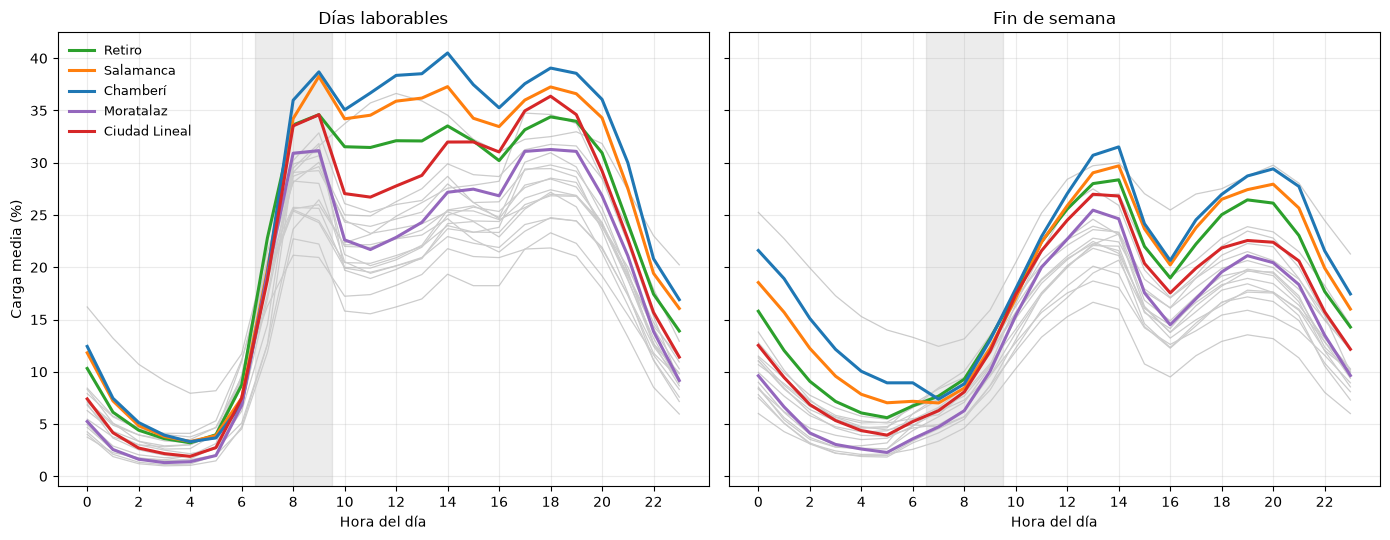

In [16]:
N_DESTACADOS = 5
destacados = ranking.head(N_DESTACADOS)["codigo"].tolist()
colores = plt.cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for codigo, nombre in DISTRITOS.items():
    lab   = df[(df["distrito"] == codigo) & (df["es_laborable"])].sort_values("hora")
    finde = df[(df["distrito"] == codigo) & (~df["es_laborable"])].sort_values("hora")
    if lab.empty:
        continue
    if codigo in destacados:
        c = colores[destacados.index(codigo)]
        kw = dict(color=c, lw=2.2, zorder=3, label=nombre)
    else:
        kw = dict(color='0.8', lw=0.9, zorder=1, label='_nolegend_')
    axes[0].plot(lab["hora"], lab["carga_media"], **kw)
    axes[1].plot(finde["hora"], finde["carga_media"], **{**kw, 'label': '_nolegend_'})

axes[0].set_title("Días laborables")
axes[1].set_title("Fin de semana")
for ax in axes:
    ax.axvspan(min(HORAS_PUNTA) - 0.5, max(HORAS_PUNTA) + 0.5, alpha=0.15, color="grey", zorder=0)
    ax.set_xlabel("Hora del día")
    ax.set_xticks(range(0, 24, 2))
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Carga media (%)")
axes[0].legend(frameon=False, fontsize=9, ncol=1)
fig.tight_layout()
fig.savefig(CARPETA_SALIDA / "perfil_horario_distritos_destacados.png", dpi=150, bbox_inches='tight')
plt.show()

## Conclusión

Tras analizar los perfiles horarios de carga media por distrito, se observa que Chamberí (distrito 7) presenta los valores de carga media más elevados durante prácticamente todo el periodo diario.


Además, este distrito muestra la mayor diferencia entre los niveles de carga registrados en días laborables y fines de semana durante la franja de hora punta, lo que indica un patrón de movilidad  condicionado por la actividad laboral.

Por estos motivos, **Chamberí** se identifica como el distrito con un comportamiento de movilidad más significativo dentro de los distritos seleccionados y pasa a ser nuestra zona de estudio.